In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import os

import pickle as pkl

'.'

In [50]:
filepath = '/Users/oshun/Documents/GitHub/zuco-benchmark/src/features/YFR_electrode_features_all.npy'
f = np.load(filepath, allow_pickle=True)

In [51]:
f1 = f.item()

In [52]:
f1.keys()

dict_keys(['YFR_NR_0_1721', 'YFR_NR_1_1722', 'YFR_NR_2_1723', 'YFR_NR_3_1724', 'YFR_NR_4_1725', 'YFR_NR_5_1726', 'YFR_NR_6_1727', 'YFR_NR_7_1728', 'YFR_NR_8_1729', 'YFR_NR_9_1730', 'YFR_NR_10_1731', 'YFR_NR_11_1732', 'YFR_NR_12_1733', 'YFR_NR_13_1734', 'YFR_NR_14_1735', 'YFR_NR_16_1736', 'YFR_NR_17_1737', 'YFR_NR_18_1738', 'YFR_NR_19_1739', 'YFR_NR_21_1740', 'YFR_NR_22_1741', 'YFR_NR_23_1742', 'YFR_NR_24_1743', 'YFR_NR_25_1744', 'YFR_NR_29_1745', 'YFR_NR_30_1746', 'YFR_NR_31_1747', 'YFR_NR_32_1748', 'YFR_NR_34_1749', 'YFR_NR_35_1750', 'YFR_NR_36_1751', 'YFR_NR_37_1752', 'YFR_NR_38_1753', 'YFR_NR_39_1754', 'YFR_NR_40_1755', 'YFR_NR_41_1756', 'YFR_NR_42_1757', 'YFR_NR_43_1758', 'YFR_NR_44_1759', 'YFR_NR_45_1760', 'YFR_NR_46_1761', 'YFR_NR_47_1762', 'YFR_NR_48_1763', 'YFR_NR_51_1764', 'YFR_NR_53_1765', 'YFR_NR_57_1766', 'YFR_NR_59_1767', 'YFR_NR_62_1768', 'YFR_NR_66_1769', 'YFR_NR_68_1770', 'YFR_NR_70_1771', 'YFR_NR_71_1772', 'YFR_NR_72_1773', 'YFR_NR_73_1774', 'YFR_NR_74_1775', 'YFR_NR_7

In [65]:
f1['YFR_NR_315_1885'][0:420:140]

[3.164538621902466, 1.5871171951293945, 1.300166130065918]

In [57]:
len(f1['YFR_NR_1_1722'])

421

In [60]:
len(f1['YFR_NR_23_1742'])

421

In [49]:
import numpy as np
import extract_features as fe
import config
import data_helpers as dh
import time
from datetime import timedelta
import pandas as pd
import mne
from mne import EvokedArray
import matplotlib.pyplot as plt

import topoplots_nr_tsr_avg


In [50]:
topoplots_nr_tsr_avg

<module 'topoplots_nr_tsr_avg' from '/Users/oshun/Documents/GitHub/zuco-benchmark/src/topoplots_nr_tsr_avg.py'>

In [51]:
import nltk

In [52]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to /Users/oshun/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [1]:
import numpy as np
import extract_features as fe
import config
import data_helpers as dh
import time
from datetime import timedelta
import pandas as pd
import mne
from mne import EvokedArray
import matplotlib.pyplot as plt


# topoplots for NR, TSR, and NR-TSR across all sentences of all subjects




start = time.time()

features_all = pd.DataFrame(columns=['subj', 'feature_set', 'sample_id', 'feature_values', 'label'])

for subject in config.subjects:
    print(subject)
    filename_nr = config.rootdir + "results" + subject + "_NR.mat"
    filename_tsr = config.rootdir + "results" + subject + "_TSR.mat"

    f_nr = dh.read_mat_file(filename_nr)
    f_tsr = dh.read_mat_file(filename_tsr)

    if config.dataset is "zuco1_sr":  # include sentiment reading as NR
        filename_sr = config.rootdir + "results" + subject + "_SR.mat"
        f_sr = dh.read_mat_file(filename_sr)

    features = {}

    for feature_set in config.feature_sets:

        features[feature_set] = {}

        fe.extract_sentence_features(subject, f_nr, feature_set, features, "NR")
        fe.extract_sentence_features(subject, f_tsr, feature_set, features, "TSR")
        if config.dataset is "zuco1_sr":
            fe.extract_sentence_features(subject, f_sr, feature_set, features, "NR")
        print(len(features[feature_set]), " samples collected for", feature_set)

        for x, y in features[feature_set].items():
            features_all = features_all.append({'subj': subject, 'feature_set': feature_set, 'sample_id': x, 'feature_values': np.array(y[:-1]), 'label':y[-1]}, ignore_index=True)

for feature_set in config.feature_sets:

    info = mne.create_info(ch_names=config.chanlocs, ch_types="eeg", sfreq=500)

    features_nr = features_all.loc[(features_all['feature_set'] == feature_set) & (features_all['label'] == 'NR')]
    mean_nr = features_nr['feature_values'].mean()

    features_tsr = features_all.loc[(features_all['feature_set'] == feature_set) & (features_all['label'] == 'TSR')]
    mean_tsr = features_tsr['feature_values'].mean()

    diff = mean_nr - mean_tsr

    # NR
    evoked_nr = EvokedArray(mean_nr.reshape(-1,1), info=info)
    evoked_nr.set_montage("GSN-HydroCel-128")
    print(evoked_nr.info)
    evoked_nr.drop_channels([0])
    print(evoked_nr.info)

    fig, ax = plt.subplots(figsize=(7.5, 4.5), nrows=1, ncols=1)
    ax = evoked_nr.plot_topomap(title='EEG patterns', time_unit='s', units='a.u.', scalings=1, vmin=min(diff), cmap='RdBu')
    plt.savefig("NR-topo-AVG-ALL"+feature_set+".pdf")
    plt.close()

    """

    # TSR
    evoked_tsr = EvokedArray(mean_tsr.reshape(-1, 1), info=info)
    evoked_tsr.set_montage("GSN-HydroCel-128")

    fig, ax = plt.subplots(figsize=(7.5, 4.5), nrows=1, ncols=1)
    ax = evoked_tsr.plot_topomap(title='EEG patterns', time_unit='s', units='a.u.', scalings=1, vmin=min(diff), cmap='RdBu')
    plt.savefig("TSR-topo-AVG-ALL"+feature_set+".pdf")
    plt.close()

    # DIFF
    evoked_diff = EvokedArray(diff.reshape(-1, 1), info=info)
    evoked_diff.set_montage("GSN-HydroCel-128")

    fig, ax = plt.subplots(figsize=(7.5, 4.5), nrows=1, ncols=1)
    ax = evoked_diff.plot_topomap(title='EEG patterns', time_unit='s', units='a.u.', scalings=1, vmin=min(diff), cmap='RdBu')
    plt.savefig("Diff-topo-AVG-ALL"+feature_set+".pdf")
    plt.close()
    """

elapsed = (time.time() - start)
print(str(timedelta(seconds=elapsed)))




YAC
360  samples collected for electrode_features_all
521  samples collected for sent_gaze_sacc
521  samples collected for sent_gaze_sacc_eeg_means


ValueError: Info (104) and data (420) must have same number of channels.

'electrode_features_all'

In [5]:
mean_nr.shape

(420,)

In [ ]:
feature_set = 'electrode_features_all'
eatures_nr = features_all.loc[(features_all['feature_set'] == feature_set) & (features_all['label'] == 'NR')]
features_nr['feature_values'] # each of the 157 has 420 in the feature values?

0      [2.5682151913642883, 1.537336826324463, 1.2549...
1      [2.3025513291358948, 1.5068343877792358, 1.292...
2      [3.4841889142990112, 2.2952221035957336, 1.661...
3      [2.773075819015503, 1.9968168139457703, 1.5521...
4      [3.2471845149993896, 1.877117097377777, 1.4816...
                             ...                        
153    [2.5230281352996826, 2.498600482940674, 2.4410...
154    [3.1701745986938477, 2.352375030517578, 1.9427...
155    [2.8425213098526, 2.08916699886322, 1.88209819...
156    [4.569487810134888, 4.038059234619141, 3.36115...
157    [3.1999577283859253, 3.261996626853943, 2.9811...
Name: feature_values, Length: 158, dtype: object

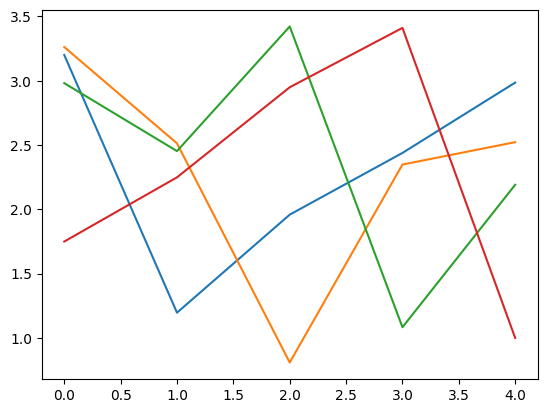

In [47]:
import matplotlib.pyplot as plt

plt.plot(features_nr['feature_values'][157][0:420:104])
plt.plot(features_nr['feature_values'][157][1:420:104])
plt.plot(features_nr['feature_values'][157][2:420:104])
plt.plot(features_nr['feature_values'][157][3:420:104])

In [38]:
features_nr['feature_values'][157][:416]

array([3.19995773, 3.26199663, 2.98118114, 1.7493751 , 1.23388803,
       0.65865543, 3.86866176, 3.79087448, 3.51083338, 3.13793564,
       0.93944034, 3.78676367, 3.70533693, 3.66344821, 2.49729073,
       2.37087238, 3.82140565, 3.26264977, 2.55914557, 2.93558347,
       2.74771166, 2.39326775, 1.11718684, 0.98695576, 0.953031  ,
       2.33874249, 2.30545056, 1.02718785, 1.06022799, 0.86675426,
       2.82474506, 1.21119046, 1.12890047, 1.02852359, 1.02717403,
       2.91114008, 2.34105265, 1.17588013, 1.02516574, 1.02890891,
       1.24727279, 1.0217132 , 1.02867031, 1.07309937, 1.47568727,
       1.37349385, 1.5141145 , 1.61113673, 1.42591196, 1.53823066,
       2.22136104, 5.69189024, 1.87823719, 2.02771533, 1.94618618,
       3.57091057, 2.68128252, 3.05245113, 4.28457332, 3.98907042,
       3.1543659 , 2.9562012 , 2.59302092, 2.69436443, 2.09253895,
       1.40183491, 0.79873464, 2.63597631, 2.23528564, 1.73364162,
       1.38789809, 1.15734076, 0.81842622, 2.42363811, 1.83512

In [27]:
info

<Info | 7 non-empty values
 bads: []
 ch_names: E2, E3, E4, E5, E6, E7, E9, E10, E11, E12, E13, E15, E16, E18, ...
 chs: 104 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 250.0 Hz
 meas_date: unspecified
 nchan: 104
 projs: []
 sfreq: 500.0 Hz
>

# From features data/train/features

In [ ]:
import h5py
import numpy as np
import pickle as pkl
import data_loading_helpers as dlh
import re
import config

In [66]:
filepath = '/Users/oshun/Documents/GitHub/zuco-benchmark/data/train/Features/resultsYFR_NR.mat'
matfile = h5py.File(filepath, 'r')

NameError: name 'h5py' is not defined